In [14]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands, plot_time_bands_median
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
train_info = GraphsTraining()

### Load Pyomo results in

In [15]:
results_pyomo = load_all_pickles("results/pyomo_rl_2026-01-07_23-36-45", recursive=False)[0]
df_reg = Results.collect_data(results_pyomo)
reg = Results.columns_to_lists(df_reg)
reg.keys()

Loaded results/pyomo_rl_2026-01-07_23-36-45/results_full.pkl

Loaded 1 files from results/pyomo_rl_2026-01-07_23-36-45


dict_keys(['Times_Elapsed', 'MSE_odeint', 'MSE_collocation', 'MSE_odeint_test', 'MSE_collocation_test'])

In [16]:
fn = "results/pyomo_rl_2026-01-07_23-36-45/results_full.pkl"
#fn = 'results/convergence_2024-09-02_17-22-56_full.pkl'
pyomo_convergence = Results.load_results(fn)

keys = {k:k for k in list(pyomo_convergence.values())[0].keys()}
pyomo_df = Results.collect_data(pyomo_convergence, keys)

df = pyomo_df.drop(columns=['result']).reset_index(drop=True)
list_cols = df.columns.tolist()

N_SEEDS = 10  # <-- set this

def seed_labels_chunked(xs, n_seeds):
    L = len(xs)
    n_steps = L // n_seeds
    return list(np.repeat(np.arange(n_seeds), n_steps))

def step_labels_chunked(xs, n_seeds):
    L = len(xs)
    n_steps = L // n_seeds
    return list(np.tile(np.arange(n_steps), n_seeds))

df['seed'] = df[list_cols[0]].apply(lambda xs: seed_labels_chunked(xs, N_SEEDS))

pyomo_long = df.explode(list_cols + ['seed'], ignore_index=True).rename(columns = {"times_elapsed":"time_elapsed", "mse_coll_ode" : "mse_train", "mse_coll_ode_test":"mse_test"})


### Load JAX results in

In [17]:
def load_jax_training_df(path, pretraining_times_li = None) -> pd.DataFrame:
    """
    Load JAX RL run pickles (WITH/NO logging) and return a long-form dataframe with
    time_elapsed, mse_train, mse_test, and seed.

    Args:
        path: Directory containing results_NO_logging.pkl and results_WITH_logging.pkl

    Returns:
        pd.DataFrame: concatenated dataframe across seeds
    """
    path = Path(path)

    with (path / "results_NO_logging.pkl").open("rb") as f:
        results_jax_no_log = pickle.load(f)

    with (path / "results_WITH_logging.pkl").open("rb") as f:
        results_jax_with_log = pickle.load(f)

    training_losses = results_jax_with_log["training_losses"]

    training_jax_df = pd.DataFrame()

    # Keep the same key order you were using
    keys_li = list(results_jax_with_log.keys())

    for i, tl in enumerate(training_losses):
        # get losses after pretraining
        if len(tl) == 2:
            tl = tl[1]
        else:
            tl = tl[0]
        # times elapsed from the NO-log run
        time_elapsed = results_jax_no_log[keys_li[i]]["times_elapsed"]

        # if staged training, override pretraining_time from the recorded value
        if pretraining_times_li is not None:
            pre_t = pretraining_times_li[i]
        else:
            pre_t = 0.0
        main_t = time_elapsed
        if isinstance(time_elapsed, (list, tuple, np.ndarray)) and len(time_elapsed) > 1:
            pre_t, main_t = float(time_elapsed[0]), float(time_elapsed[1])
        else:
            main_t = float(time_elapsed) - float(pre_t)

        # tl is expected to be [train_losses, test_losses]
        train_losses = tl[0]
        test_losses = tl[1]

        # avoid divide-by-zero if only one point
        denom = max(1, len(train_losses) - 1)
        time_elapsed_per_segment = main_t / denom

        times = np.array([time_elapsed_per_segment * j for j in range(len(train_losses))], dtype=float)
        times += float(pre_t)

        df = pd.DataFrame(
            {
                "time_elapsed": times,
                "mse_train": train_losses,
                "mse_test": test_losses,
                "seed": i,
            }
        )
        training_jax_df = pd.concat([training_jax_df, df], ignore_index=True)

    return training_jax_df

In [18]:
path = Path("results/jax_rl_runs/jax_rl_2026-01-11_11-34-17/")
with (path / "results_NO_logging.pkl").open("rb") as f:
    results_jax_no_log = pickle.load(f)

In [19]:
# df = load_jax_training_df("results/jax_rl_runs/jax_rl_2026-01-10_03-44-07/")
times_li = [v["times_elapsed_split"][0] for v in results_jax_no_log.values()]
training_jax_df = load_jax_training_df("results/jax_rl_runs/jax_rl_2026-01-10_03-44-07/", pretraining_times_li=times_li)
training_jax_no_pretrain_df = load_jax_training_df("results/jax_rl_runs/jax_rl_2026-01-10_13-29-52/")


### Load PyTorch results in

In [20]:
def load_pytorch_training_df(path) -> pd.DataFrame:
    """
    Load JAX RL run pickles (WITH/NO logging) and return a long-form dataframe with
    time_elapsed, mse_train, mse_test, and seed.

    Args:
        path: Directory containing results_NO_logging.pkl and results_WITH_logging.pkl

    Returns:
        pd.DataFrame: concatenated dataframe across seeds
    """
    path = Path(path)

    with (path / "results_NO_logging.pkl").open("rb") as f:
        results_pytorch_no_log = pickle.load(f)

    with (path / "results_WITH_logging.pkl").open("rb") as f:
        results_pytorch_with_log = pickle.load(f)

    training_pytorch_df = pd.DataFrame()

    for i, key in enumerate(results_pytorch_with_log.keys()):
        # get losses after pretraining
        tl = results_pytorch_with_log[key]["training_losses"]
        # times elapsed from the NO-log run
        time_elapsed = results_pytorch_no_log[key]["time_elapsed"]

        if isinstance(time_elapsed, (list, tuple, np.ndarray)):
            if len(time_elapsed) > 1:
                pre_t, main_t = float(time_elapsed[0]), float(time_elapsed[1])
            else:
                main_t = float(time_elapsed[0])
                pre_t = 0.0
        else:
            main_t = float(time_elapsed)
            pre_t = 0.0

        # tl is expected to be [train_losses, test_losses]
        train_losses = tl[0]
        test_losses = tl[1]

        # avoid divide-by-zero if only one point
        denom = max(1, len(train_losses) - 1)
        time_elapsed_per_segment = main_t / denom

        times = np.array([time_elapsed_per_segment * j for j in range(len(train_losses))], dtype=float)
        times += float(pre_t)

        df = pd.DataFrame(
            {
                "time_elapsed": times,
                "mse_train": train_losses,
                "mse_test": test_losses,
                "seed": i,
            }
        )
        training_pytorch_df = pd.concat([training_pytorch_df, df], ignore_index=True)

    return training_pytorch_df

In [21]:
training_pytorch_df = load_pytorch_training_df("results/pytorch_rl_runs/pytorch_rl_2026-01-10_17-21-26/")
training_pytorch_no_pretrain_df = load_pytorch_training_df("results/pytorch_rl_runs/pytorch_rl_2026-01-10_18-46-32/")
training_pytorch_pyomo_pretrain_df = load_pytorch_training_df("results/pytorch_rl_2026-01-16_22-00-38/")
# training_pyomo_pretrain_df = load_pytorch_training_df("results/pyomo_rl_2026-01-16_21-58-38/")

In [22]:
training_pytorch_pyomo_pretrain_df = training_pytorch_pyomo_pretrain_df[training_pytorch_pyomo_pretrain_df["time_elapsed"] != 0]

In [23]:
results_pyomo = load_all_pickles("results/pyomo_rl_2026-01-16_21-58-38", recursive=False)[0]

pretraining_times = [i["result"]["solver_time"] for i in list(results_pyomo.values())]

for i in range(len(pretraining_times)):
    t = pretraining_times[i]
    training_pytorch_pyomo_pretrain_df.loc[training_pytorch_pyomo_pretrain_df['seed'] == i, 'time_elapsed'] += t

Loaded results/pyomo_rl_2026-01-16_21-58-38/results_full.pkl

Loaded 1 files from results/pyomo_rl_2026-01-16_21-58-38


In [24]:
pyomo_long = pyomo_long[pyomo_long["time_elapsed"] <= 9.0]

comparison_dfs = {
    "Pyomo": pyomo_long,
    "JAX": training_jax_df,
    "PyTorch": training_pytorch_df}

comparison_dfs_no_pretrain = {
    "Pyomo": pyomo_long,
    "JAX_no_pretrain": training_jax_no_pretrain_df,
    "PyTorch_no_pretrain": training_pytorch_no_pretrain_df}

In [28]:
comparison_df_pytorch = {
    "PyTorch_no_pretrain": training_pytorch_no_pretrain_df,
    "PyTorch": training_pytorch_df,
    "PyTorch_pyomo_pretrain": training_pytorch_pyomo_pretrain_df}



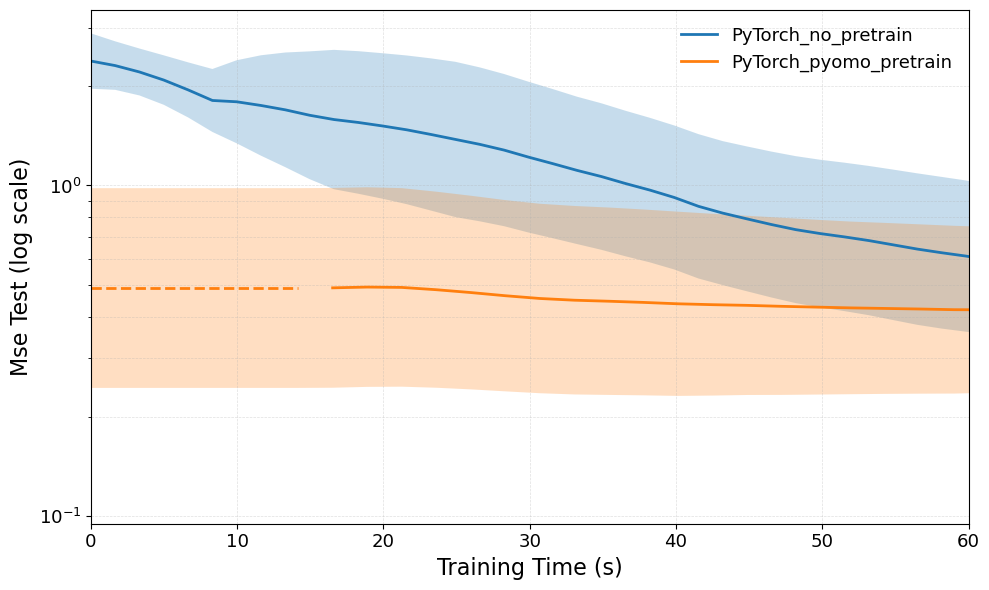

<Axes: xlabel='Training Time (s)', ylabel='Mse Test (log scale)'>

In [33]:
plot_time_bands(
    comparison_df_pytorch,
    y_col="mse_test",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    tmax_quantile=1,
    xlim =(0, 60)
)

In [31]:
df = pd.DataFrame(results).T
df

NameError: name 'results' is not defined

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:702: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


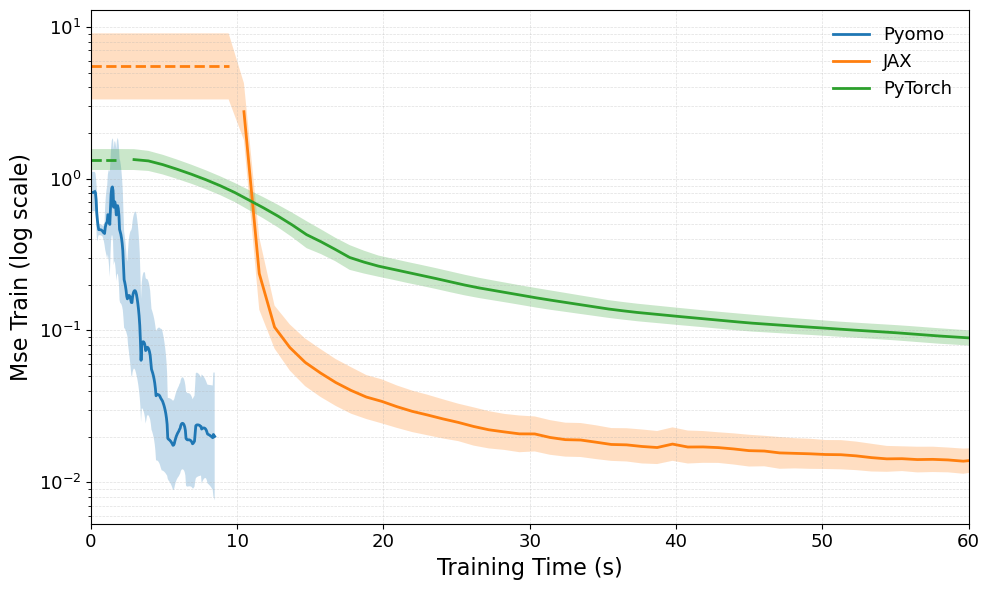

<Axes: xlabel='Training Time (s)', ylabel='Mse Train (log scale)'>

In [200]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    tmax_quantile=1,
    xlim =(0, 60)
)

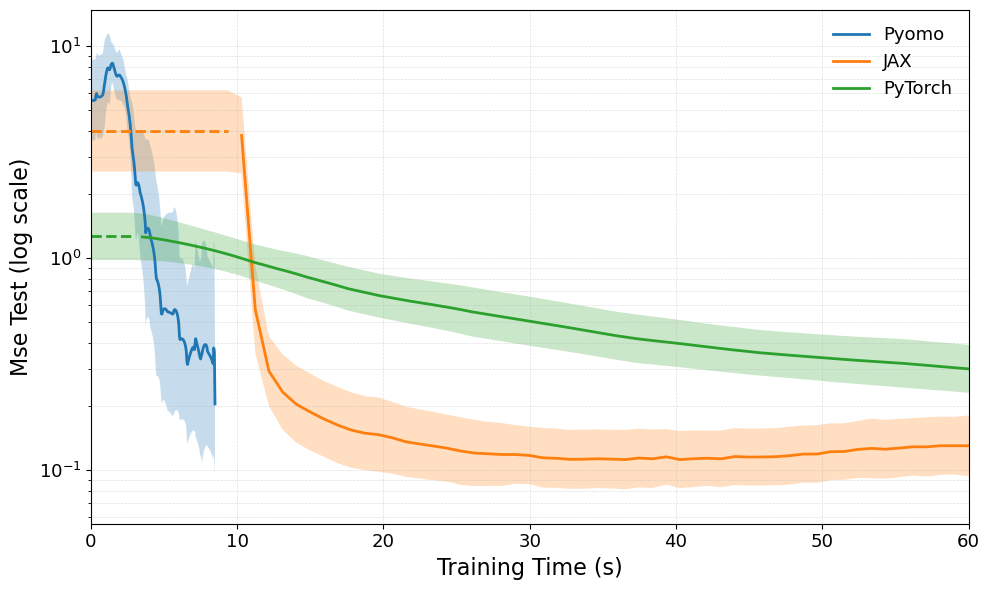

<Axes: xlabel='Training Time (s)', ylabel='Mse Test (log scale)'>

In [201]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_test",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    tmax_quantile=0.5,
    xlim =(0, 60)
)

----

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:702: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


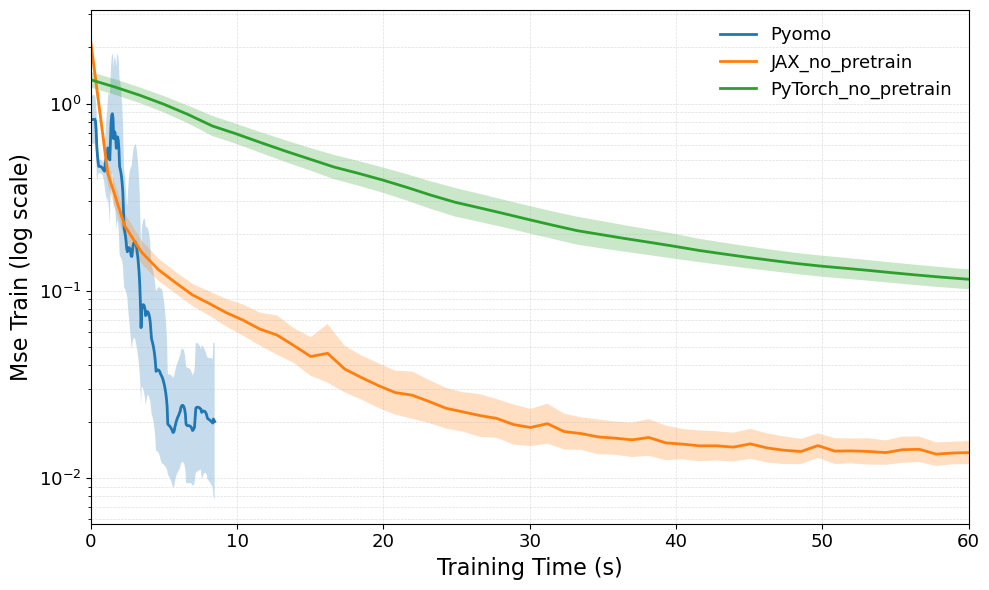

<Axes: xlabel='Training Time (s)', ylabel='Mse Train (log scale)'>

In [203]:
plot_time_bands(
    comparison_dfs_no_pretrain,
    y_col="mse_train",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    tmax_quantile=1,
    xlim =(0, 60)
)

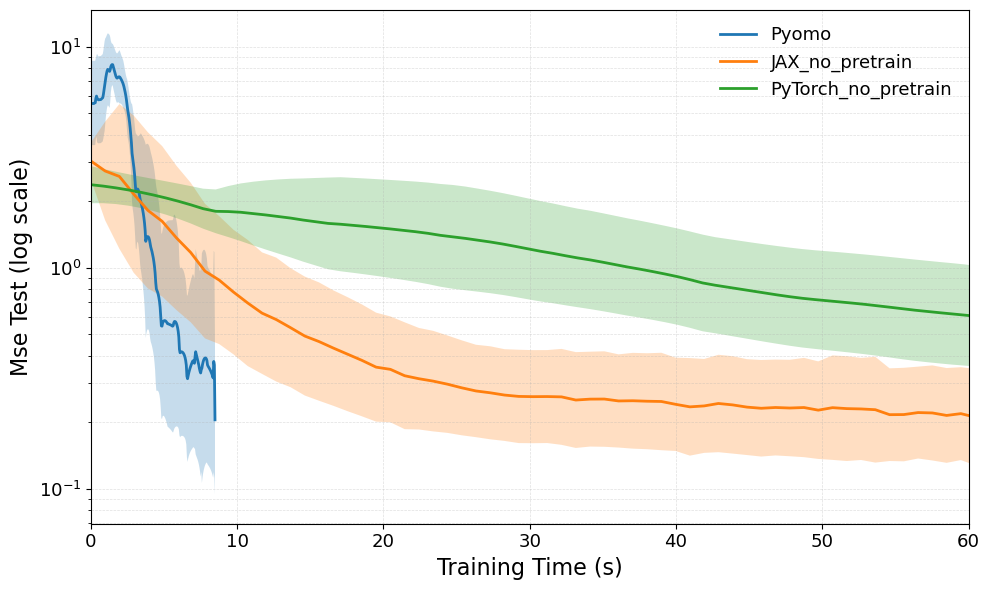

<Axes: xlabel='Training Time (s)', ylabel='Mse Test (log scale)'>

In [204]:
plot_time_bands(
    comparison_dfs_no_pretrain,
    y_col="mse_test",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    tmax_quantile=0.5,
    xlim =(0, 60)
)